### Explanation of Code for Climate Data Clustering with Self-Organizing Map (SOM)

### Check the library and how to install it

https://github.com/doan-van/S-SOM-V1



### step-by-step breakdown:

1. **Import Libraries and Define File Paths**
   - The necessary libraries (`xarray`, `numpy`, and `SSOM`) are imported.
   - Paths are defined for the climate data directory and dataset.

2. **Load Climate Data**
   - The dataset is loaded using `xarray.open_dataset()`, which enables handling multi-dimensional climate data stored in a NetCDF file.

3. **Create a Land-Sea Mask**
   - A mask is generated to identify valid (non-NaN) data points for both `air_temperature` and `precipitation` at the first time step.
   - The mask is converted to binary, with `1` representing valid data and `0` invalid.

4. **Normalize Variables Over Time**
   - **Mean and Standard Deviation Calculation**: The mean and standard deviation for both `air_temperature` and `precipitation` are calculated across the dataset.
   - **Normalization**: Each variable is normalized to have a mean of 0 and a standard deviation of 1, making data comparable across different variables.

5. **Flatten and Concatenate Data**
   - **Flattening**: Each variable is flattened across latitude and longitude, resulting in 2D arrays with 12 time steps and a number of samples corresponding to spatial grid points.
   - **Concatenation**: Temperature and precipitation data are concatenated along a new axis to form a single dataset with 24 time points per sample, capturing seasonal variability.

6. **Filter Out NaN Samples**
   - Using the `land_sea_mask`, only valid samples (where data exists for both variables) are retained, ensuring that the SOM processes only complete data points.

7. **Initialize and Train the Self-Organizing Map (SOM)**
   - A SOM with a 5x5 grid is initialized using Euclidean distance as the metric.
   - The SOM is trained on the filtered data, learning patterns in the normalized climate data.

8. **Extract SOM Clusters and Assign Labels**
   - **Cluster Extraction**: The SOM’s grid structure is obtained, and each sample is assigned to a specific cluster on the SOM grid.
   - **Cluster Mapping**: The cluster assignments are mapped back to the spatial grid, creating a `clustered_map` that labels each valid point with its corresponding cluster.

9. **Map Clusters onto Original Land-Sea Structure**
   - `clustered_map` is initialized as a copy of `land_sea_mask`, and `0`s are set to `NaN` to exclude non-valid points.
   - Finally, each valid point in `clustered_map` is assigned a cluster label, completing the spatial clustering of climate data.


In [1]:
import xarray as xr
import numpy as np
from ssom import SSOM

# Define directories and file paths
data_dir = '/Users/doan/MyDrive/share/2024/clim_class_data/'  # Shared Google Drive data directory
dataset_path = f'{data_dir}21789074/climate_data_0p1/1991_2020/ensemble_mean_0p1.nc'

# Load the climate dataset
climate_data = xr.open_dataset(dataset_path)
print(climate_data)

# Step 1: Create a land-sea mask with valid data for both air temperature and precipitation
land_sea_mask = ~np.isnan(climate_data['air_temperature'].isel(time=0)) & ~np.isnan(climate_data['precipitation'].isel(time=0))
land_sea_mask = land_sea_mask.astype(int)  # Convert to 1 (valid) and 0 (invalid)

# Step 2: Normalize each variable over time
temp_mean = climate_data['air_temperature'].mean() #dim='time')
temp_std = climate_data['air_temperature'].std() #dim='time')
precip_mean = climate_data['precipitation'].mean() #dim='time')
precip_std = climate_data['precipitation'].std() #dim='time')

temperature_norm = (climate_data['air_temperature'] - temp_mean) / temp_std
precipitation_norm = (climate_data['precipitation'] - precip_mean) / precip_std

# Step 3: Convert to NumPy arrays and concatenate along the new 24-point dimension
temperature_flat = temperature_norm.stack(sample=("lat", "lon")).values  # Shape: (12, num_samples)
precipitation_flat = precipitation_norm.stack(sample=("lat", "lon")).values  # Shape: (12, num_samples)

# Concatenate along the new 24-time-point axis
combined_data_np = np.concatenate([temperature_flat, precipitation_flat], axis=0)  # Shape: (24, num_samples)
combined_data_np = combined_data_np.T  # Transpose to shape (num_samples, 24)

# Step 4: Filter out NaN samples using the land-sea mask
valid_mask = land_sea_mask.stack(sample=("lat", "lon")).values  # Flatten the mask
data_matrix = combined_data_np[valid_mask == 1, :]  # Keep only valid samples

<xarray.Dataset> Size: 622MB
Dimensions:          (lon: 3600, lat: 1800, time: 12)
Coordinates:
  * lon              (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
  * lat              (lat) float64 14kB 89.95 89.85 89.75 ... -89.85 -89.95
  * time             (time) float64 96B 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
Data variables:
    precipitation    (time, lat, lon) float32 311MB ...
    air_temperature  (time, lat, lon) float32 311MB ...
Attributes:
    history:  Created on 2024-02-19 06:56


In [2]:
# Step 5: Initialize and train the Self-Organizing Map (SOM) on the normalized climate data
#som = SSOM(grid_size=[5, 5], num_iterations=2171421, max_learning_rate=0.5, metric="euclidean")
som = SSOM(grid_size=20, grid_shape = '1D', num_iterations=2171421, max_learning_rate=0.5, metric="euclidean")
som.train(data_matrix)

SSOM Initial Settings:
  Grid Shape: 1D
  Grid Size: 20
  Number of Iterations: 2171421
  Max Learning Rate: 0.5
  Learning Decay: 0.25
  Neighborhood Decay: 0.5
  Metric: euclidean
  Log Interval: 21714

Initialized SOM grid with random weights.
Iter 2171421/2171421 [==================================================]  LearnRate: 0.0092


In [3]:
som_grid = som.som_grid
clusters = np.array([ s[1] for s in som.sample_bmu_mapping])
#clusters = np.array([s[1][0] * 5 + s[1][1] for s in som.sample_bmu_mapping])

# Step 7: Create a new map with cluster labels mapped onto the original land-sea structure
clustered_map = land_sea_mask.astype(float).copy()
# Replace 0s with NaN in clustered_map
clustered_map = clustered_map.where(clustered_map != 0, np.nan)
clustered_map.values[land_sea_mask.values == 1] = clusters  # Assign clusters only to valid land-sea points

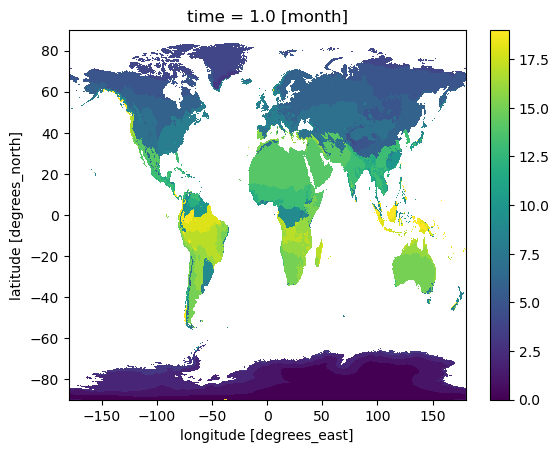

In [8]:
clustered_map.to_netcdf('climate_class_bySOM.nc')
clustered_map.plot()


### Explanation of Code for Denormalizing and Reshaping SOM Grid

Reshapes and denormalizes the SOM grid for `air_temperature` and `precipitation`, restoring the original scale of each variable after clustering. 

1. **Reshape SOM Grid for Each Variable**
   - The `som_grid` output from the SOM is split along the last dimension, separating the temperature and precipitation data:
     - `temp_som` extracts the first 12 time points, representing temperature.
     - `precip_som` extracts the last 12 time points, representing precipitation.
   - This step restores the structure of the data, allowing us to handle each variable independently.

2. **Denormalize Each Variable**
   - After normalization, data values are scaled and centered. To bring them back to their original scale, denormalization is performed:
     - `temp_som_denormalized` is calculated by multiplying `temp_som` with the standard deviation of `air_temperature` (`temp_std`) and adding the mean (`temp_mean`).
     - `precip_som_denormalized` is similarly calculated for `precipitation` using `precip_std` and `precip_mean`.
   - This denormalization step restores the temperature and precipitation data to their original units, making the SOM output directly interpretable in terms of real-world values.

3. **Recombine Denormalized Variables**
   - Finally, the denormalized temperature and precipitation arrays are recombined along the last dimension (time).
   - `som_grid_denormalized` is created by concatenating `temp_som_denormalized` and `precip_som_denormalized`, resulting in an array that represents both variables across the original time points.

In [4]:
# Reshape the SOM grid to the original dimensions for each variable
#temp_som = som_grid[..., :12]  # First 12 time points for temperature
#precip_som = som_grid[..., 12:]  # Last 12 time points for precipitation

# Reshape the SOM grid to the original dimensions for each variable
temp_som = som_grid[:, :12]  # First 12 time points for temperature
precip_som = som_grid[:, 12:]  # Last 12 time points for precipitation

# Denormalize each variable separately
temp_som_denormalized = (temp_som * temp_std.values) + temp_mean.values
precip_som_denormalized = (precip_som * precip_std.values) + precip_mean.values

# Recombine the denormalized variables along the last dimension (time)
som_grid_denormalized = np.concatenate([temp_som_denormalized, precip_som_denormalized], axis=-1)


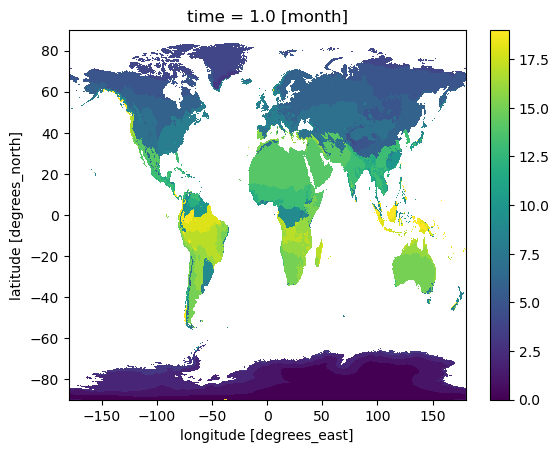

# Plot results

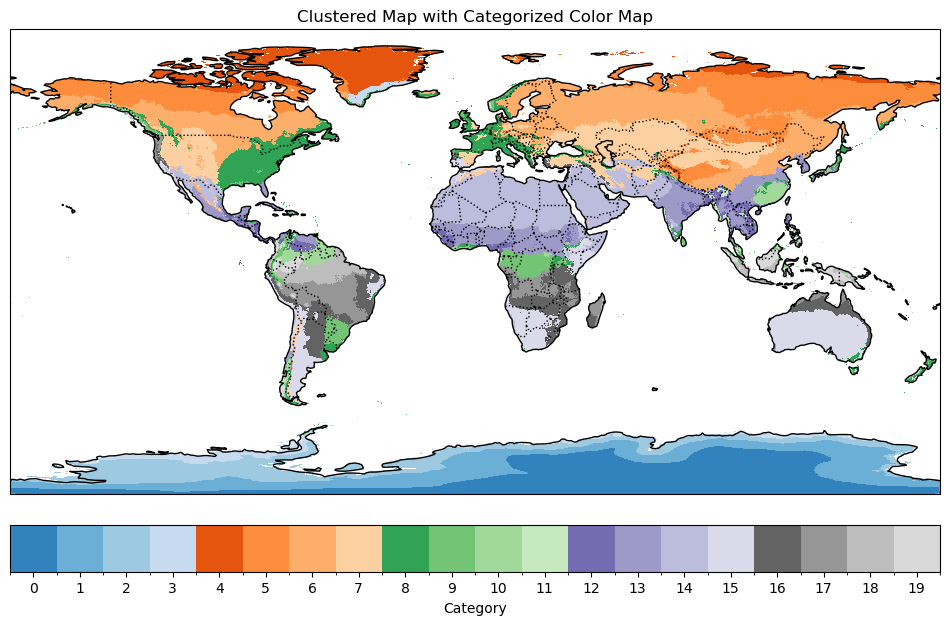

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# Convert clustered_map to a masked array to ensure NaN values are handled properly
masked_data = np.ma.masked_invalid(clustered_map)

# Get the minimum and maximum values from masked_data
min_value = int(np.nanmin(clustered_map))
max_value = int(np.nanmax(clustered_map))
num_categories = max_value - min_value + 1

# Create a discrete colormap with enough colors for each category
cmap = plt.get_cmap('tab20c', num_categories)  # Use 'tab20c' for distinct colors
cmap.set_bad(color=(1.0, 1.0, 1.0, 0.0))  # Set NaN values to fully transparent

# Define a BoundaryNorm to map categories to color bins
bounds = np.arange(min_value - 0.5, max_value + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Set up the plot with a PlateCarree projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# Add geographical features for context
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
#ax.add_feature(cfeature.LAND, facecolor='lightgrey')
#ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot the data with the discrete colormap
mesh = ax.pcolormesh(
    clustered_map['lon'], clustered_map['lat'], masked_data,
    cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
)

# Create a color bar with separate patches for each category
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, spacing='uniform')
cbar.set_label('Category')
cbar.set_ticks(np.arange(min_value, max_value + 1))  # Center ticks based on categories
cbar.set_ticklabels([str(i) for i in range(min_value, max_value + 1)])  # Label each category


# Set the title
plt.title('Clustered Map with Categorized Color Map')
plt.show()


In [10]:
import matplotlib.pyplot as plt
def plot_hythergraph( temperature,precipitation, title = 'Climograph'):
    # plotting
    # Example monthly climate data
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    lab1, lab2, lab3 = 'Temperature (°C)', 'Min Temperature (°C)', 'Precipitation (mm)'
    tit1 = 'Hythergraph: Monthly Temperature and Precipitation\n'
    xlab, ylab1, ylab2 = 'Month', 'Temperature (°C)', 'Precipitation (mm)'

    # Create figure and axis
    fig = plt.figure(figsize= [6,4] )
    ax1 = plt.axes( [.15,.2,.7,.65] )

    # Plot temperature data
    ax1.plot(months, temperature, 'o--', color='darkred', label=lab1)
    ax1.set_xlabel(xlab)
    ax1.set_ylabel(ylab1, color='darkred')
    ax1.tick_params(axis='y', labelcolor='darkred')

    # Create a second y-axis to plot precipitation
    ax2 = ax1.twinx()
    ax2.bar(months, precipitation, alpha=0.3, color='green', label=lab3)
    ax2.set_ylabel(ylab2, color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Add title and show plot
    plt.title(title)
    fig.legend(loc='lower left', fontsize=9,ncols = 3, bbox_to_anchor=(0.2, -0.0))
    return fig

In [13]:
som_grid_denormalized.shape

(20, 24)

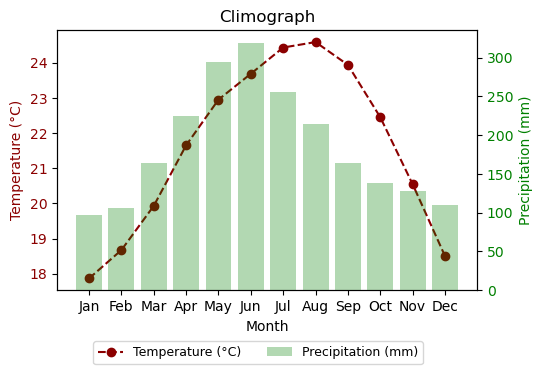

In [16]:
ind = 10
tp = som_grid_denormalized[ind]
temp = som_grid_denormalized[ind][:12]
prcp = som_grid_denormalized[ind][12:]
fig = plot_hythergraph(temp,prcp, title = 'Climograph')